# AICE Associate 예상 문제 7회: 농작물 수확량 예측

**과제: 환경 데이터 기반 농작물 수확량 예측 AI 모델 개발**

**도메인: 농업/환경**

**배경:**
기후 변화와 환경 요인은 농작물 생산량에 직접적인 영향을 미칩니다. 'AICE 스마트팜' 연구소는 정밀 농업 기술을 발전시키기 위해, 다양한 지역에서 수집된 기상, 토양, 재배 데이터를 분석하고자 합니다. 이 분석을 통해 어떤 환경 조건이 수확량에 중요한 영향을 미치는지 파악하고, 특정 조건에서 예상되는 수확량을 예측하는 AI 모델을 개발하는 것이 목표입니다. 이 모델은 농가의 생산성 향상과 안정적인 식량 공급 계획 수립에 기여할 것입니다.

**데이터셋 설명 (파일명: `7_crop_yield_prediction.csv`)**

* `annual_rainfall_mm`: 연간 총 강수량
* `avg_temp`: 연평균 기온
* `sunshine_hours`: 연간 총 일조 시간
* `soil_type`: 토양의 종류 (sandy, loam, clay)
* `soil_ph`: 토양의 산성도
* `fertilizer_type`: 사용된 주 비료 (nitrogen, phosphorus, potassium, complex)
* `nitrogen_concentration`: 토양 내 질소 농도
* `phosphorus_concentration`: 토양 내 인 농도
* `potassium_concentration`: 토양 내 칼륨 농도
* **`yield_kg_per_ha`**: **예측 목표(Target)**, 헥타르(ha)당 수확량 (kg)

---
#### **사전 실행 코드**
> 모든 문제를 풀기 전에 아래 코드를 실행해주세요.

In [1]:
# 데이터 분석 및 시각화에 필요한 기본 라이브러리들을 불러옵니다.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn 라이브러리에서 필요한 모듈들을 불러옵니다.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# TensorFlow Keras 라이브러리를 불러옵니다.
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

---
#### **문제 1.**

Scikit-learn 라이브러리의 `linear_model` 모듈에는 다양한 선형 회귀 모델들이 포함되어 있습니다. `sklearn.linear_model` 모듈에서 `Lasso` 클래스를 임포트하는 코드를 작성하세요.

In [2]:
# 여기에 답안코드를 작성하세요.
from sklearn.linear_model import Lasso

---
#### **문제 2.**

AI 모델링을 위해 분석할 데이터를 준비하고 기본적인 정보를 파악하려고 합니다. 아래 가이드에 따라 코드를 작성하세요.

1.  Pandas의 `read_csv` 함수를 사용하여 `7_crop_yield_prediction.csv` 파일을 읽어 데이터프레임 변수 `crop_df`에 할당하세요.
2.  `info()` 함수를 사용하여 `crop_df`의 요약 정보를 확인하여 결측치와 데이터 타입을 파악하세요.

In [3]:
# 여기에 답안코드를 작성하세요.
crop_df = pd.read_csv('7_crop_yield_prediction.csv')

---
#### **문제 3.**

예측 목표인 `yield_kg_per_ha` 데이터의 분포를 시각적으로 탐색하고자 합니다.  
`seaborn`의 `histplot`을 사용하여 `yield_kg_per_ha` 컬럼의 분포를 히스토그램으로 나타내세요.

* **대상 컬럼**: `yield_kg_per_ha`
* **데이터**: `crop_df`
* **추가 옵션**: `kde=True`를 사용하여 밀도 추정 곡선을 함께 표시

<Axes: xlabel='yield_kg_per_ha', ylabel='Count'>

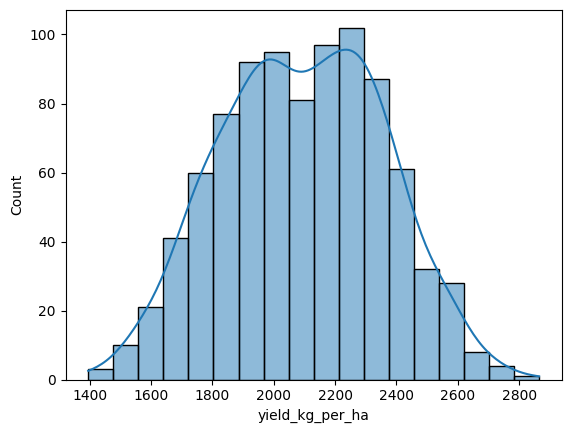

In [4]:
# 여기에 답안코드를 작성하세요.
sns.histplot(data=crop_df, x='yield_kg_per_ha', kde=True)

---
#### **문제 4.**

`soil_type`에 따라 `yield_kg_per_ha`의 분포가 어떻게 다른지 확인하려고 합니다.  
`seaborn`의 `boxplot`을 사용하여 토양타입별 수확량 분포를 시각화하고, 수확량의 중앙값이 가장 낮은 토양 타입을 `답안04` 변수에 문자열로 저장하세요.

* **x축**: `soil_type`
* **y축**: `yield_kg_per_ha`
* **데이터**: `crop_df`

In [5]:
# 한글화를 위해 아래의 코드를 작성해 주세요.
import platform
from matplotlib import rc

if platform.system() == 'Darwin':  # macOS
    rc('font', family='AppleGothic')
else:  # Windows
    rc('font', family='Malgun Gothic')

plt.rcParams['axes.unicode_minus'] = False

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 50577 (\N{HANGUL SYLLABLE YANG}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 53664 (\N{HANGUL SYLLABLE TO}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 51656 (\N{HANGUL SYLLABLE JIL}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}

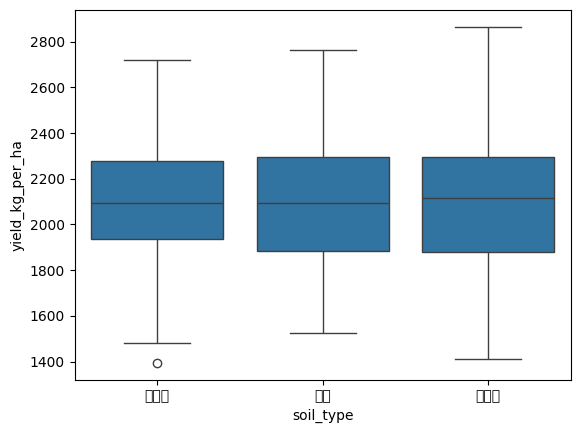

In [9]:
# 여기에 답안코드를 작성하세요.
sns.boxplot(data=crop_df, x='soil_type', y='yield_kg_per_ha')

crop_df.groupby('soil_type')['yield_kg_per_ha'].median()

# 그래프를 보고 수확량의 중앙값이 가장 낮은 토양 타입을 아래 변수에 저장하세요.
답안04 = ['사양토', '양토']

---
#### **문제 5.**

`fertilizer_type`별로 각 영양소(`nitrogen_concentration`, `phosphorus_concentration`, `potassium_concentration`)의 평균 농도를 비교하고자 합니다. `groupby()`를 사용하여 데이터를 `fertilizer_type`으로 그룹화하고, 세 가지 영양소 농도 컬럼의 평균을 계산하세요.

In [10]:
# 여기에 답안코드를 작성하세요.
concentration_list = ['nitrogen_concentration', 'phosphorus_concentration', 'potassium_concentration']
crop_df.groupby('fertilizer_type')[concentration_list].mean()

,nitrogen_concentration,phosphorus_concentration,potassium_concentration
fertilizer_type,,,
복합,55.314223,27.543147,27.848207
인,55.079120,28.144352,28.286065
질소,54.204813,26.920000,27.679486
칼륨,54.856438,25.033196,27.129498


---
#### **문제 6.**

모델링을 위해 데이터의 결측치를 처리하려고 합니다. 아래 가이드에 따라 결측치를 처리하고, 결과를 `crop_pre` 변수에 저장하세요.

1.  `crop_df` 데이터프레임을 복사하여 `crop_pre`를 생성합니다.
2.  `avg_temp`와 `sunshine_hours` 컬럼의 결측치는 각 컬럼의 **평균값(mean)** 으로 채우세요.

In [12]:
# 여기에 답안코드를 작성하세요.
crop_pre = crop_df.copy()

colum_list = ['avg_temp', 'sunshine_hours']

for i in colum_list:
  crop_pre[i] = crop_pre[i].fillna(crop_pre[i].mean())

crop_pre.isnull().sum()

,0
annual_rainfall_mm,0
avg_temp,0
sunshine_hours,0
soil_type,0
soil_ph,0
fertilizer_type,0
nitrogen_concentration,0
phosphorus_concentration,0
potassium_concentration,0
yield_kg_per_ha,0


---
#### **문제 7.**

모델이 이해할 수 있도록 범주형 데이터를 수치형으로 변환하려고 합니다. 아래 가이드에 따라 두 가지 다른 방식으로 인코딩을 수행하세요.

1.  순서 정보가 중요하지 않은 `fertilizer_type` 컬럼은 `pandas`의 `get_dummies()`를 사용하여 **원-핫 인코딩**을 수행하세요.
2.  `soil_type` 컬럼은 `sklearn.preprocessing`의 `LabelEncoder`를 사용하여 **레이블 인코딩**을 수행하세요.
3.  모든 변환은 `crop_pre` 데이터프레임에 직접 적용하세요.

In [14]:
# 여기에 답안코드를 작성하세요.
crop_pre = pd.get_dummies(
    data=crop_pre, columns=['fertilizer_type']
)

le = LabelEncoder()

crop_pre['soil_type'] = le.fit_transform(crop_pre['soil_type'])

crop_pre.head()

,annual_rainfall_mm,avg_temp,sunshine_hours,soil_type,soil_ph,nitrogen_concentration,phosphorus_concentration,potassium_concentration,yield_kg_per_ha,fertilizer_type_복합,fertilizer_type_인,fertilizer_type_질소,fertilizer_type_칼륨
0,1760.0,22.1,2698.0,0,6.9,35.95,33.37,34.39,2422.0,False,False,True,False
1,656.0,22.8,1546.0,0,5.2,23.64,31.49,10.71,1708.0,True,False,False,False
2,821.0,12.7,2346.0,1,6.3,45.34,30.08,5.47,1811.0,False,False,False,True
3,1461.0,24.1,2451.0,2,7.5,25.66,10.42,19.26,2025.0,False,True,False,False
4,503.0,22.8,2442.0,0,5.4,16.74,24.89,44.89,1568.0,False,True,False,False


---
#### **문제 8.**

기존 변수를 조합하여 새로운 특성, `질소/칼륨 비율`을 생성하려고 합니다. `crop_pre` 데이터프레임에 `nitro_potassium_ratio`라는 새로운 컬럼을 추가하고, `nitrogen_concentration / potassium_concentration` 값을 계산하여 할당하세요.

* **주의**: `potassium_concentration`이 0인 경우 0으로 나누는 에러가 발생할 수 있으므로, `potassium_concentration`이 0일 때는 `nitro_potassium_ratio` 값도 0이 되도록 처리하세요.

In [15]:
# 여기에 답안코드를 작성하세요.
crop_pre['nitro_potassium_ratio'] = np.where(
    crop_pre['potassium_concentration'] == 0,
    0,
    crop_pre['nitrogen_concentration'] / crop_pre['potassium_concentration']
)

crop_pre.head()

,annual_rainfall_mm,avg_temp,sunshine_hours,soil_type,soil_ph,nitrogen_concentration,phosphorus_concentration,potassium_concentration,yield_kg_per_ha,fertilizer_type_복합,fertilizer_type_인,fertilizer_type_질소,fertilizer_type_칼륨,nitro_potassium_ratio
0,1760.0,22.1,2698.0,0,6.9,35.95,33.37,34.39,2422.0,False,False,True,False,1.045362
1,656.0,22.8,1546.0,0,5.2,23.64,31.49,10.71,1708.0,True,False,False,False,2.207283
2,821.0,12.7,2346.0,1,6.3,45.34,30.08,5.47,1811.0,False,False,False,True,8.288848
3,1461.0,24.1,2451.0,2,7.5,25.66,10.42,19.26,2025.0,False,True,False,False,1.332295
4,503.0,22.8,2442.0,0,5.4,16.74,24.89,44.89,1568.0,False,True,False,False,0.372912


---
#### **문제 9.**

훈련과 검증에 사용할 데이터셋을 분리하려고 합니다. `yield_kg_per_ha` 컬럼을 label `y`로, 나머지 컬럼들을 feature `X`로 할당한 후 훈련 데이터셋과 검증 데이터셋으로 분리하는 코드를 작성하세요.

* **대상 데이터셋**: `crop_pre` (8번 문제까지 처리 완료된)
* **훈련:검증 데이터 비율**: 80:20
* **`random_state`**: 2024

In [16]:
# 여기에 답안코드를 작성하세요.
X = crop_pre.drop('yield_kg_per_ha', axis=1)
y = crop_pre['yield_kg_per_ha']

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=2024
)

---
#### **문제 10.**

수치형 데이터들의 단위를 맞춰주기 위해 데이터 스케일링을 진행합니다. 평균을 0, 표준편차를 1로 변환하는 `StandardScaler`를 사용하여 훈련 데이터와 검증 데이터의 Feature(`X_train`, `X_valid`)를 스케일링하는 코드를 작성하세요.

* 훈련 데이터에는 `fit_transform()`을, 검증 데이터에는 `transform()`을 적용하세요.
* 스케일링된 결과는 각각 `X_train_scaled`, `X_valid_scaled` 변수에 저장하세요.

In [17]:
# 여기에 답안코드를 작성하세요.
ss = StandardScaler()
X_train_scaled = ss.fit_transform(X_train)
X_valid_scaled = ss.transform(X_valid)

---
#### **문제 11.**

L1 규제를 사용하여 불필요한 변수의 영향력을 0으로 만드는 특징이 있는 `Lasso` 회귀 모델을 사용하여 수확량 예측 모델을 학습시키려고 합니다. 아래 가이드에 따라 모델을 생성하고 학습시키는 코드를 작성하세요.

* `sklearn.linear_model`의 `Lasso` 함수 사용 (1번 문제에서 임포트)
* **하이퍼파라미터 설정**:
    * `alpha`: 0.5
    * `random_state`: 2024
* 모델 객체는 `model_lasso` 변수에 저장하고, 스케일링된 훈련 데이터로 학습시키세요.
* 모델 예측은 `lasso_pred` 변수에 저장하세요.

In [18]:
# 여기에 답안코드를 작성하세요.
model_lasso = Lasso(
    alpha = 0.5, random_state=2024
)

model_lasso.fit(X_train_scaled, y_train)

Lasso(alpha=0.5, random_state=2024)

---
#### **문제 12.**

이번에는 `RandomForestRegressor` 모델을 사용하여 학습을 진행하고, 이 모델의 예측 성능을 확인하려고 합니다. 아래 가이드에 따라 모델을 학습시키고, 검증 데이터셋(`X_valid_scaled`)에 대한 예측 결과를 `rf_pred` 변수에 저장하세요.

* `sklearn.ensemble`의 `RandomForestRegressor` 함수 사용
* **하이퍼파라미터 설정**:
    * `n_estimators`: 150
    * `max_depth`: 8
    * `random_state`: 2024
* 모델 객체는 `model_rf` 변수에 저장하고 학습시키세요.

In [19]:
# 여기에 답안코드를 작성하세요.
model_rf = RandomForestRegressor(
    n_estimators = 150,
    max_depth = 8,
    random_state = 2024
)

model_rf.fit(X_train_scaled, y_train)

RandomForestRegressor(max_depth=8, n_estimators=150, random_state=2024)

---
#### **문제 13.**

앞서 학습한 두 머신러닝 모델(`model_lasso`, `model_rf`)의 성능을 평가하려고 합니다. 회귀 모델의 성능을 평가하는 대표적인 지표인 **MAE(Mean Absolute Error)** 와 **R² Score(결정계수)** 를 계산하는 코드를 작성하세요.

* 두 모델에 대해 각각 두 가지 평가지표를 모두 계산하고 출력하세요.

In [20]:
# 여기에 답안코드를 작성하세요.
lasso_pre = model_lasso.predict(X_valid)
rf_pre = model_rf.predict(X_valid)

print("Lasso 성능")
print(f"MAE: {mean_absolute_error(y_valid, lasso_pre)}")
print(f"R2: {r2_score(y_valid, lasso_pre)}")
print("RF 성능")
print(f"MAE: {mean_absolute_error(y_valid, rf_pre)}")
print(f"R2: {r2_score(y_valid, rf_pre)}")

Lasso 성능
MAE: 444546.2643967559
R2: -3136767.9192184606
RF 성능
MAE: 437.7618882648216
R2: -2.8172736303414645


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but Lasso was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


---
#### **문제 14.**

이번에는 딥러닝을 사용하여 수확량 예측 모델을 만들려고 합니다. 아래의 가이드에 따라 `tensorflow.keras`를 사용하여 회귀 모델을 구축하고, 학습시킨 후, 새로운 데이터에 대한 예측을 수행하세요.

1.  **모델 구축**:
    * `Sequential` 모델
    * **입력층**: `Dense` 레이어, 32개 노드, 활성화 함수 `relu`
    * **은닉층**: `Dense` 레이어, 16개 노드, 활성화 함수 `relu`
    * **출력층**: `Dense` 레이어, 1개 노드
2.  **컴파일**: `optimizer='adam'`, `loss='mean_squared_error'`
3.  **학습**: `epochs=50`, `batch_size=32`, `validation_data` 사용
4.  **예측**: 아래 `new_crop_data`를 **10번 문제에서 생성한 스케일러(`scaler`)를 사용하여 변환**한 뒤, 학습된 딥러닝 모델로 수확량을 예측하여 `predicted_yield_dl` 변수에 저장하세요.

In [21]:
# 아래 코드를 실행하여 시뮬레이션용 데이터를 생성하세요.
new_crop_data = np.array([[1500, 20.0, 2500.0, 1, 6.5, 35.0, 30.0, 40.0, 1, 0, 0, 0, 0.875]])

In [23]:
# 여기에 답안코드를 작성하세요.
model = Sequential([
    Dense(32, activation='relu', input_shape=[X_train_scaled.shape[1]]),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(
    optimizer='adam', loss='mean_squared_error'
)

model.fit(X_train_scaled, y_train, epochs=50, batch_size=32, validation_data=(X_valid_scaled, y_valid))

new_crop_scaled = ss.transform(new_crop_data)

predicted_yield_dl = model.predict(new_crop_scaled)

print(predicted_yield_dl[0][0])

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 4431272.5000 - val_loss: 4538378.5000
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4425993.5000 - val_loss: 4532773.0000
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4419480.0000 - val_loss: 4525509.0000
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4410898.0000 - val_loss: 4515765.5000
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4399395.0000 - val_loss: 4502908.5000
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4384288.5000 - val_loss: 4485922.0000
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4364446.0000 - val_loss: 4463954.5000
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4338973.5000 - val_loss: 4435890.0000
Epoch 9/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4306870.5000 - val_loss: 4400744.0000
Epoch 10/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4266624.0000 - val_loss: 4357923.5000
Epoch 11/50
23/23 ━━━━━━━━━━━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step
2257.418
